#                         Customer Segmentation Using KMeans Clustering

### Summary

This project performs customer segmentation using advanced behavioral features such as RFM (Recency, Frequency, Monetary), Customer Lifetime Value (CLV), spending behavior, and demographic attributes.  
Using KMeans clustering and dimensionality reduction techniques (PCA and UMAP), four distinct customer segments were identified.

These segments reveal clear differences in customer value, loyalty, and purchasing behavior, enabling targeted marketing strategies, improved retention, and optimized revenue generation.


## Business Problem

Businesses often treat all customers the same, resulting in inefficient marketing spend and missed revenue opportunities.  
Customer segmentation helps identify high-value customers, at-risk customers, and price-sensitive groups so the business can tailor strategies for each segment.

The goal of this project is to uncover meaningful customer groups that support:
- Personalized marketing
- Retention strategies
- Revenue optimization
- Improved customer experience

## Dataset Overview

The dataset contains customer demographic and behavioral attributes, including:

- **Income** – purchasing power  
- **Spending Score** – engagement level  
- **Age** – demographic insight  
- **Membership Years** – loyalty duration  
- **Recency** – how recently a customer purchased  
- **Frequency** – how often they purchase  
- **Monetary** – how much they spend  
- **CLV** – long-term revenue potential  

These features allow us to build a rich, multi-dimensional view of customer behavior.

In [ ]:
#loading the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#loading the dataset
df = pd.read_csv('/content/customer_segmentation.csv')

In [ ]:
#checking the size of dataset
df.shape

(1000, 9)

In [ ]:
df.head()


,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   object 
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   object 
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB


# Data Preprocessing and Cleaning

In [ ]:
#descriptive statistics
df.describe()

,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,43.783000,88500.800000,50.685000,5.46900,26.596000,492.348670
std,288.819436,15.042213,34230.771122,28.955175,2.85573,14.243654,295.744253
min,1.000000,18.000000,30004.000000,1.000000,1.00000,1.000000,10.400000
25%,250.750000,30.000000,57911.750000,26.000000,3.00000,15.000000,218.762500
50%,500.500000,45.000000,87845.500000,50.000000,5.00000,27.000000,491.595000
75%,750.250000,57.000000,116110.250000,76.000000,8.00000,39.000000,747.170000
max,1000.000000,69.000000,149973.000000,100.000000,10.00000,50.000000,999.740000


In [ ]:
df.describe(include = 'object').T

,count,unique,top,freq
gender,1000,3,Male,357
preferred_category,1000,5,Electronics,215


In [ ]:
df['preferred_category'].value_counts()

,count
preferred_category,
Electronics,215
Sports,210
Home & Garden,206
Groceries,199
Clothing,170


In [ ]:
#checking for null values
df.isnull().sum()

,0
id,0
age,0
gender,0
income,0
spending_score,0
membership_years,0
purchase_frequency,0
preferred_category,0
last_purchase_amount,0


In [ ]:
#checking for duplicated values
df.duplicated().sum()

np.int64(0)

In [ ]:
#dropping the id variable which is not required
df = df.drop('id', axis = 1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1000 non-null   int64  
 1   gender                1000 non-null   object 
 2   income                1000 non-null   int64  
 3   spending_score        1000 non-null   int64  
 4   membership_years      1000 non-null   int64  
 5   purchase_frequency    1000 non-null   int64  
 6   preferred_category    1000 non-null   object 
 7   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(5), object(2)
memory usage: 62.6+ KB


## Feature Engineering

### RFM Metrics
- **Recency**: How recently a customer purchased  
- **Frequency**: How often they purchase  
- **Monetary**: How much they spend  

RFM is a widely used framework for understanding customer engagement and value.

### Customer Lifetime Value (CLV)
CLV estimates the long-term revenue a customer is expected to generate.  
Combining CLV with RFM provides a deeper understanding of customer value.

In [ ]:
# Creating RFM features

#Recency feature, Since dates are not available ,using higer purchase frequency for more recent purchase and longer membership for more recent activity

df['recency'] = 1 / df['purchase_frequency']

#Since we already have purchase frequency feature

#For creating monetary , using last purchase amount and spending score
df['monetary'] = df['last_purchase_amount'] * (df['spending_score']/100)

#Creating customer lifetime value
df['clv'] = df['last_purchase_amount']*df['membership_years']*df['purchase_frequency']

#Creating price sensitivity score
df['price_sensitivity'] = (df['last_purchase_amount'] / df['income']) * (100 - df['spending_score'])


df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1000 non-null   int64  
 1   gender                1000 non-null   object 
 2   income                1000 non-null   int64  
 3   spending_score        1000 non-null   int64  
 4   membership_years      1000 non-null   int64  
 5   purchase_frequency    1000 non-null   int64  
 6   preferred_category    1000 non-null   object 
 7   last_purchase_amount  1000 non-null   float64
 8   recency               1000 non-null   float64
 9   monetary              1000 non-null   float64
 10  clv                   1000 non-null   float64
 11  price_sensitivity     1000 non-null   float64
dtypes: float64(5), int64(5), object(2)
memory usage: 93.9+ KB


,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount,recency,monetary,clv,price_sensitivity
0,38,Female,99342,90,3,24,Groceries,113.53,0.041667,102.1770,8174.16,0.011428
1,21,Female,78852,60,2,42,Sports,41.93,0.023810,25.1580,3522.12,0.021270
2,60,Female,126573,30,2,28,Clothing,424.36,0.035714,127.3080,23764.16,0.234688
3,40,Other,47099,74,9,5,Home & Garden,991.93,0.200000,734.0282,44636.85,0.547574
4,65,Female,140621,21,3,25,Electronics,347.08,0.040000,72.8868,26031.00,0.194987


Encoding the categorical variables

# Customer Segmentation using K-means Clustering

In [ ]:
# Selecting the numerical features

X = df.select_dtypes(include=['int64','float64'])
print(X)

     age  income  spending_score  membership_years  purchase_frequency  \
0     38   99342              90                 3                  24   
1     21   78852              60                 2                  42   
2     60  126573              30                 2                  28   
3     40   47099              74                 9                   5   
4     65  140621              21                 3                  25   
..   ...     ...             ...               ...                 ...   
995   57  112170              57                 6                   1   
996   23   65337              76                10                  23   
997   23  113097              40                 5                  42   
998   22  113695              63                 7                  44   
999   36   90420               7                 2                  31   

     last_purchase_amount   recency  monetary        clv  
0                  113.53  0.041667  102.1770    817

In [ ]:
# checking the correlation between the variables
corr = X.corr()
print(corr)

                           age    income  spending_score  membership_years  \
age                   1.000000 -0.000688        0.017707         -0.003431   
income               -0.000688  1.000000        0.000020         -0.035783   
spending_score        0.017707  0.000020        1.000000          0.026726   
membership_years     -0.003431 -0.035783        0.026726          1.000000   
purchase_frequency   -0.030137  0.000533        0.006708          0.069532   
last_purchase_amount  0.061599 -0.054006       -0.014475         -0.014135   
recency               0.017586 -0.029755       -0.028930         -0.044776   
monetary              0.073366 -0.033842        0.630396          0.028470   
clv                   0.033786 -0.027451        0.044146          0.500849   

                      purchase_frequency  last_purchase_amount   recency  \
age                            -0.030137              0.061599  0.017586   
income                          0.000533             -0.054006 -0.0

In [ ]:
#Scaling the data before clustering
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
#Applying PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

Choosing the number of clusters

Text(0.5, 1.0, 'Elbow method')

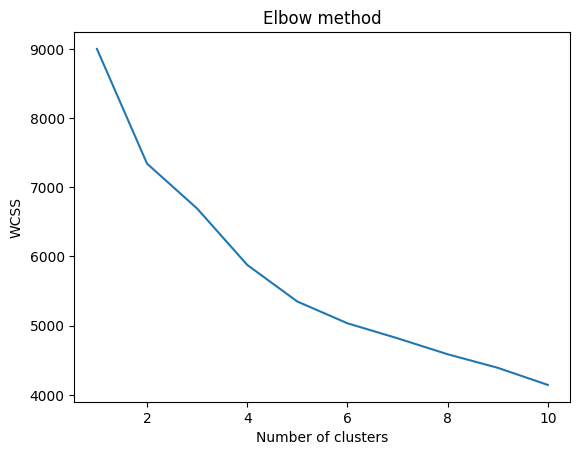

In [ ]:
# finding wcss values for different number of clusters
from sklearn.cluster import KMeans
wcss = []

for i in range(1,11):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

#Plotting the cluster value
plt.plot(range(1,11), wcss)
plt.xlabel('Number of clusters')
plt.ylabel("WCSS")
plt.title("Elbow method")



In [ ]:
#Using the silhouette score to choose the optimal number of clusters
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in range(2,11):
 kmeans = KMeans(n_clusters=k, random_state=42)
 labels = kmeans.fit_predict(X_scaled)
 score = silhouette_score(X_scaled, labels)
 print(f"k ={k}, silhouette score = {score:4f}")



k =2, silhouette score = 0.180297
k =3, silhouette score = 0.136561
k =4, silhouette score = 0.162385
k =5, silhouette score = 0.147054
k =6, silhouette score = 0.144527
k =7, silhouette score = 0.137295
k =8, silhouette score = 0.133053
k =9, silhouette score = 0.135503
k =10, silhouette score = 0.140605


Two methods were used:

### 1. Elbow Method
The elbow curve showed a noticeable bend around **k = 4**, suggesting diminishing returns beyond this point.

### 2. Silhouette Score
Silhouette scores peaked at **k = 2**, but k = 4 provided a better balance between mathematical separation and business interpretability.

### Final Choice: **k = 4**
This value captures both the dominant customer base and the smaller, high-impact segments.

 Training the K-Means Clustering Model

KMeans clustering was applied with **k = 4**.  
Cluster labels were assigned to each customer for further analysis.

In [ ]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)
print(Y)

[0 0 0 2 0 0 0 3 1 1 0 2 0 1 1 0 0 0 2 0 1 3 2 2 2 0 1 0 1 2 3 0 0 0 3 1 0
 3 0 0 0 0 0 3 2 0 1 1 0 2 0 2 2 3 2 2 0 2 1 1 1 0 1 0 1 2 1 0 0 3 0 3 1 0
 0 2 0 0 0 2 3 0 0 0 0 0 3 0 1 2 0 2 0 0 2 0 0 3 2 0 1 0 0 1 0 3 3 2 0 3 3
 2 0 0 0 3 2 3 3 0 2 0 0 2 2 0 2 3 2 3 3 0 3 0 2 0 0 2 0 2 3 0 3 1 3 1 0 2
 2 0 2 1 3 1 2 2 2 0 2 0 2 2 0 3 0 3 0 1 0 3 0 0 3 2 0 2 0 0 0 0 1 0 0 0 2
 3 0 0 2 2 0 0 0 3 0 0 3 0 0 0 3 3 1 0 3 2 3 0 0 1 2 0 3 2 2 3 0 0 2 2 0 0
 3 1 0 0 3 0 2 0 0 0 0 0 0 3 2 2 3 0 1 2 0 2 2 0 0 0 3 0 0 2 0 3 0 0 2 2 0
 2 0 0 3 2 3 2 2 0 0 0 1 0 2 2 2 0 2 2 2 2 3 3 3 0 0 0 2 0 2 2 3 2 2 0 2 0
 0 0 0 2 0 0 3 3 2 2 0 0 1 0 0 3 0 2 0 0 2 2 2 0 0 0 2 3 2 2 3 3 0 0 3 2 1
 0 0 2 0 3 0 0 1 2 0 0 1 0 0 0 2 0 0 1 3 2 1 3 0 2 2 2 2 0 2 2 0 3 2 0 0 3
 1 2 2 0 0 0 2 2 0 1 3 0 0 0 2 3 2 0 0 1 2 1 2 2 3 2 0 1 3 2 2 1 0 0 0 3 2
 3 2 3 1 2 0 1 2 2 1 3 0 3 2 0 0 1 0 2 1 0 0 1 0 3 3 3 2 2 0 0 2 3 3 0 0 0
 0 0 3 1 1 0 0 0 0 2 0 1 0 1 2 2 2 2 3 2 0 1 0 2 3 0 3 0 2 0 0 0 0 0 0 0 0
 0 0 0 3 0 0 2 1 0 0 3 2 

# Cluster Visualization

### PCA Visualization
PCA reduces the high-dimensional feature space into two components.

<function matplotlib.pyplot.show(close=None, block=None)>

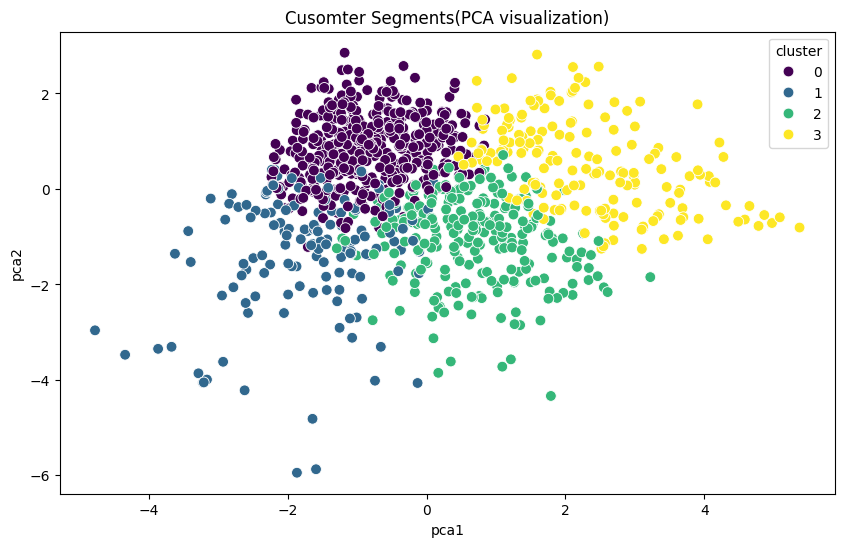

In [ ]:

import seaborn as sns

df['pca1'] = pca_components[:,0]
df['pca2'] = pca_components[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(data =df, x='pca1', y='pca2', hue='cluster', palette='viridis', s=60)
plt.title("Cusomter Segments(PCA visualization)")
plt.show

The PCA plot shows two large , dense clusters which are cluster 0 and 2 , and two smaller , more smaller , more scattered clusters-cluster 1 & 3 indicating more meaningful behavioral difference

### UMAP Visualization
UMAP captures non-linear relationships and reveals natural shapes in customer behavior.  

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<function matplotlib.pyplot.show(close=None, block=None)>

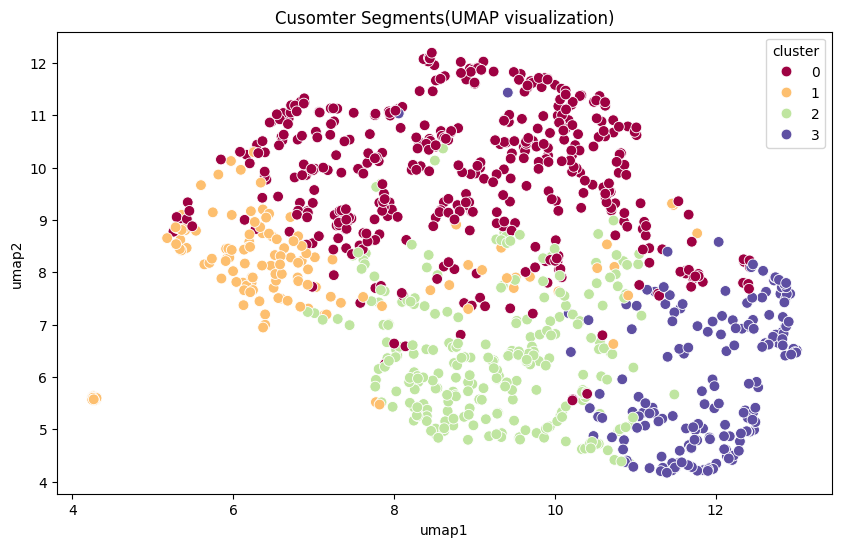

In [ ]:
import umap.umap_ as umap

reducer = umap.UMAP(n_neighbors=15,min_dist=0.1, random_state=42)
umap_components = reducer.fit_transform(X_scaled)

df['umap1'] = umap_components[:,0]
df['umap2'] = umap_components[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(data =df, x='umap1', y='umap2', hue='cluster', palette='Spectral', s=60)
plt.title("Cusomter Segments(UMAP visualization)")
plt.show



The UMAP plot confirms the presence of distinct customer groups, validating the choice of k = 4.

## Cluster Profiles

A heatmap was generated using RFM, CLV, and behavioral features.

In [ ]:
#RFM  cluster profile for interpreting clusters

cluster_profile = df.groupby('cluster')[['income','spending_score','age','membership_years','recency','purchase_frequency','monetary','clv']].mean().round(2)

cluster_profile



,income,spending_score,age,membership_years,recency,purchase_frequency,monetary,clv
cluster,,,,,,,,
0,89042.36,41.55,41.85,5.32,0.04,30.34,89.85,39914.32
1,88379.85,40.13,44.28,5.13,0.32,4.95,160.98,12662.65
2,89027.01,69.47,46.22,4.14,0.06,23.42,461.52,59230.49
3,86466.47,54.24,44.67,8.06,0.03,38.68,400.66,226046.46


<function matplotlib.pyplot.show(close=None, block=None)>

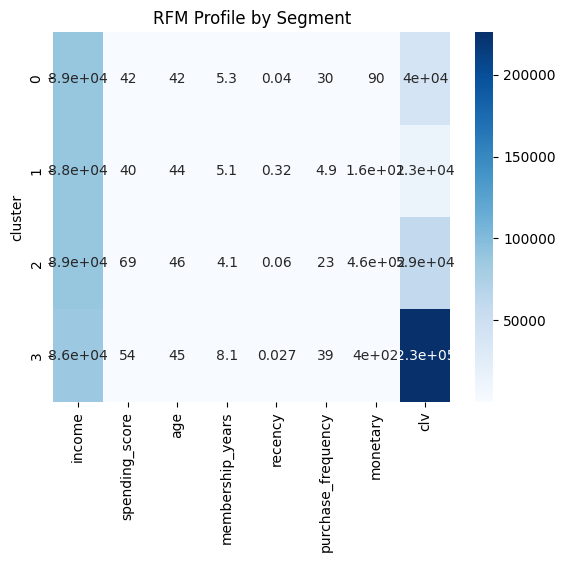

In [ ]:
rfm_cols= ['income','spending_score','age','membership_years','recency','purchase_frequency','monetary','clv']
sns.heatmap(df.groupby('cluster')[rfm_cols].mean(),annot=True, cmap='Blues')
plt.title('RFM Profile by Segment')
plt.show

The heatmap highlights clear differences in spending behavior, loyalty, and long-term value across clusters.

These profiles form the basis for business interpretation and strategy.

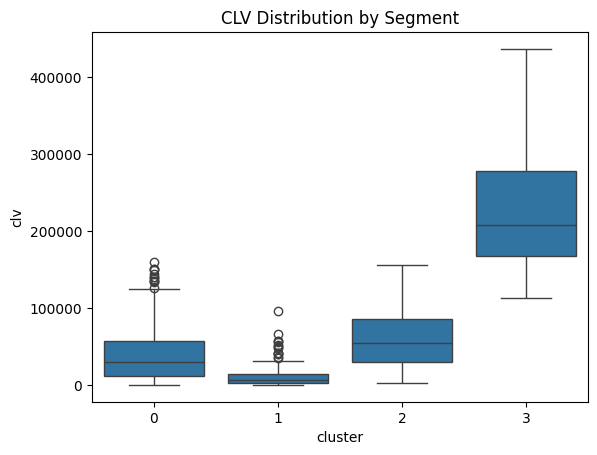

In [ ]:
#CLV Distribution per Segment

sns.boxplot(data=df,x='cluster',y='clv')
plt.title('CLV Distribution by Segment')
plt.show()

The boxplot for Customer Lifetime Value depicts the highest value for cluster 3 followed by cluster 2 .

## Business Interpretation of Segments

### Cluster 3 — High-Value Loyalists
- Highest CLV (£230K)
- Frequent purchases
- Longest membership
- Very low recency


### Cluster 2 — High-Spending Active Customers
- High monetary value (£460)
- Strong spending score
- Good frequency


### Cluster 0 — Mid-Value Stable Customers
- Moderate CLV
- Consistent purchasing behavior

### Cluster 1 — At-Risk Low-Engagement Customers
- High recency
- Low frequency
- Lowest CLV


## Business Recommendations

- **Retain high-value customers (Cluster 3)** through exclusive benefits and loyalty programs.  
- **Increase revenue from Cluster 2** via targeted upselling and personalized product bundles.  
- **Grow Cluster 0** by encouraging repeat purchases and offering tailored incentives.  
- **Reduce churn in Cluster 1** with reactivation campaigns and personalized discounts.

These strategies help optimize marketing spend and maximize customer lifetime value.

## Conclusion

This segmentation analysis reveals four distinct customer groups with clear behavioral and value differences.  
By leveraging RFM, CLV, and advanced clustering techniques, the business can implement targeted strategies that improve retention, increase revenue, and enhance customer satisfaction.

The insights generated provide a strong foundation for data-driven decision-making and personalized marketing.